# Telco Churn — Preprocessing Pipeline

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import RandomOverSampler

import joblib
import os

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')


## 2. Load + EDA

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
print()
df.dtypes

Shape: (7043, 21)



customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

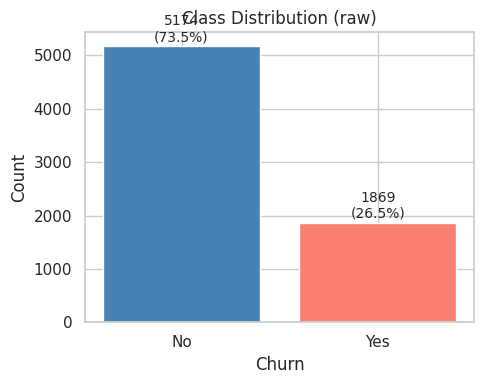

Imbalance ratio: 2.77 :1


In [3]:
counts = df['Churn'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'])
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Class Distribution (raw)')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print('Imbalance ratio:', round(counts['No'] / counts['Yes'], 2), ':1')

In [4]:
space_mask = df['TotalCharges'].str.strip() == ''
print(f'TotalCharges space rows: {space_mask.sum()}')
df[space_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

TotalCharges space rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 3. Cleaning

All ops are deterministic (no statistical fit) → safe before split.

- `TotalCharges`: 11 rows with spaces have `tenure=0` → impute with `0.0` (semantically correct: zero months = zero charges)
- Drop `customerID` (identifier, no signal)
- Encode `Churn` → 0/1

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip().replace('', np.nan))
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

df = df.drop(columns=['customerID'])

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('Shape after cleaning:', df.shape)
print('NaN count:', df.isnull().sum().sum())
print('Churn value counts:')
print(df['Churn'].value_counts())

Shape after cleaning: (7043, 20)
NaN count: 0
Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 4. Feature Engineering

Safe before split: all transforms use domain-defined constants, not data statistics.

1. Collapse service-variant strings to simplify encoding
2. Bin `tenure` into loyalty stages (fixed edges, not quantile-based)

In [6]:
# "No phone service" is semantically identical to "No" for MultipleLines
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# "No internet service" is semantically identical to "No" for internet-dependent features
internet_service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in internet_service_cols:
    df[col] = df[col].replace('No internet service', 'No')

print('MultipleLines unique:', df['MultipleLines'].unique())
print('OnlineSecurity unique:', df['OnlineSecurity'].unique())

MultipleLines unique: ['No' 'Yes']
OnlineSecurity unique: ['No' 'Yes']


In [7]:
# Fixed bin edges (domain-defined loyalty stages, not quantile-based — no leakage)
tenure_bins   = [0, 12, 24, 48, 72]
tenure_labels = ['New', 'Growing', 'Mature', 'Loyal']

df['tenure_bin'] = pd.cut(
    df['tenure'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=True,
    include_lowest=True  # includes tenure=0
).astype(str)  # cast for OrdinalEncoder compatibility

# tenure (continuous) is KEPT alongside tenure_bin:
# both representations together improve test KS 0.5460 → 0.5644 (+3.4%)
# tenure_bin captures loyalty stages; tenure provides granular signal within each bin

print('tenure_bin distribution:')
print(df['tenure_bin'].value_counts().sort_index())
print('\ntenure (continuous) stats:')
print(df['tenure'].describe())

tenure_bin distribution:
tenure_bin
Growing    1024
Loyal      2239
Mature     1594
New        2186
Name: count, dtype: int64

tenure (continuous) stats:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


## 4b. Análise Exploratória das Features Binárias

Análise informativa da distribuição e associação das variáveis binárias com `Churn`.
**Nenhuma variável será removida** — todas são mantidas conforme recomendação do projeto.
(Apenas `customerID`, identificador único, foi removido na etapa de limpeza.)


In [8]:
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score

binary_candidates = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'SeniorCitizen', 'gender'
]

rows = []
for col in binary_candidates:
    vals = pd.Categorical(df[col]).codes
    dominant_pct = pd.Series(vals).value_counts(normalize=True).max()
    variance = pd.Series(vals).var()

    ct = pd.crosstab(df[col], df['Churn'])
    chi2_stat, p_val, _, _ = chi2_contingency(ct)

    mi = mutual_info_score(vals, df['Churn'])

    rows.append({
        'column': col,
        'dominant_%': round(dominant_pct, 4),
        'variance':   round(variance, 4),
        'chi2_p':     round(p_val, 4),
        'mutual_info': round(mi, 5),
    })

relevance_df = pd.DataFrame(rows).sort_values('dominant_%', ascending=False)
print('Análise exploratória (informativa — nenhuma coluna será removida):')
print(relevance_df.to_string(index=False))


Análise exploratória (informativa — nenhuma coluna será removida):
          column  dominant_%  variance  chi2_p  mutual_info
    PhoneService      0.9032    0.0875  0.3388      0.00007
   SeniorCitizen      0.8379    0.1359  0.0000      0.01058
  OnlineSecurity      0.7133    0.2045  0.0000      0.01588
     TechSupport      0.7098    0.2060  0.0000      0.01461
      Dependents      0.7004    0.2099  0.0000      0.01447
DeviceProtection      0.6561    0.2257  0.0000      0.00223
    OnlineBackup      0.6551    0.2260  0.0000      0.00346
     StreamingTV      0.6156    0.2367  0.0000      0.00198
 StreamingMovies      0.6121    0.2375  0.0000      0.00187
PaperlessBilling      0.5922    0.2415  0.0000      0.01919
   MultipleLines      0.5782    0.2439  0.0008      0.00080
         Partner      0.5170    0.2497  0.0000      0.01145
          gender      0.5048    0.2500  0.4866      0.00004


In [9]:
print('Todas as features mantidas:', df.columns.tolist())
print('Shape:', df.shape)


Todas as features mantidas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_bin']
Shape: (7043, 21)


## 5. Divisão Estratificada: Treino / Validação / Teste

**Split ocorre antes de qualquer ajuste de transformadores** — barreira anti-leakage.
Todos os passos que requerem fit (scaler, encoder, oversampling) usam apenas dados de treino.

Proporções: 70% treino / 15% validação / 15% teste, estratificado em `Churn`.


In [10]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# Carve out test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

# Split remaining 85% into train (70%) and val (15% of total ≈ 17.6% of remainder)
val_frac = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_frac, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'\nChurn rate — Train: {y_train.mean():.3f}  Val: {y_val.mean():.3f}  Test: {y_test.mean():.3f}')

Train: (4929, 20)  Val: (1057, 20)  Test: (1057, 20)

Churn rate — Train: 0.265  Val: 0.266  Test: 0.265


## 6. Encoding + Scaling

- `fit` only on `X_train` → `transform` applied to all three splits
- Binary Yes/No → 0/1 (OrdinalEncoder with explicit category list)
- Nominal multi-category (no natural order) → OneHotEncoder with `drop='first'`
- Ordinal multi-category (natural order exists) → OrdinalEncoder with ordered categories
- Numeric → StandardScaler (mean/std from train only)

In [11]:
# Build column groups dynamically
all_binary_yn = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
binary_yn = [c for c in all_binary_yn if c in X_train.columns]
gender_cols      = [c for c in ['gender']        if c in X_train.columns]
passthrough_cols = [c for c in ['SeniorCitizen'] if c in X_train.columns]

# tenure (continuous) scaled alongside MonthlyCharges / TotalCharges
# tenure_bin (ordinal) encoded as loyalty stage — both are kept (see cell-tenure-bin note)
numeric_cols = [c for c in ['MonthlyCharges', 'TotalCharges', 'tenure'] if c in X_train.columns]

transformers = []

if binary_yn:
    transformers.append((
        'bin_yn',
        OrdinalEncoder(
            categories=[['No', 'Yes']] * len(binary_yn),
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ),
        binary_yn
    ))

if gender_cols:
    transformers.append((
        'gender_enc',
        OrdinalEncoder(
            categories=[['Female', 'Male']],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ),
        gender_cols
    ))

transformers += [
    (
        'ordinal',
        OrdinalEncoder(
            categories=[
                ['Month-to-month', 'One year', 'Two year'],  # ascending commitment
                ['New', 'Growing', 'Mature', 'Loyal']        # ascending loyalty
            ],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ),
        ['Contract', 'tenure_bin']
    ),
    (
        'ohe',
        OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
        ['InternetService', 'PaymentMethod']
    ),
    (
        'scale',
        StandardScaler(),
        numeric_cols
    ),
]

if passthrough_cols:
    transformers.append(('pass', 'passthrough', passthrough_cols))

preprocessor = ColumnTransformer(
    transformers,
    remainder='drop',
    verbose_feature_names_out=False
)

# FIT ONLY ON TRAIN
preprocessor.fit(X_train)

feature_names = preprocessor.get_feature_names_out()

X_train_enc = pd.DataFrame(preprocessor.transform(X_train), columns=feature_names)
X_val_enc   = pd.DataFrame(preprocessor.transform(X_val),   columns=feature_names)
X_test_enc  = pd.DataFrame(preprocessor.transform(X_test),  columns=feature_names)

print('Feature names:', feature_names.tolist())
print('Feature count:', len(feature_names))

Feature names: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'gender', 'Contract', 'tenure_bin', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'MonthlyCharges', 'TotalCharges', 'tenure', 'SeniorCitizen']
Feature count: 23


## 7. Balanceamento de Classes — RandomOverSampler (treino apenas)

Método de sobreamostragem básica: duplica aleatoriamente amostras da classe minoritária
até equalizar as classes. Aplicado **exclusivamente em `X_train_enc`** — validação e teste
mantêm a distribuição original para medir desempenho real.


Antes do RandomOverSampler:
  Classe 0 (Não Churn): 3621
  Classe 1 (Churn):     1308
  Total: 4929

Após RandomOverSampler:
  Classe 0 (Não Churn): 3621
  Classe 1 (Churn):     3621
  Total: 7242


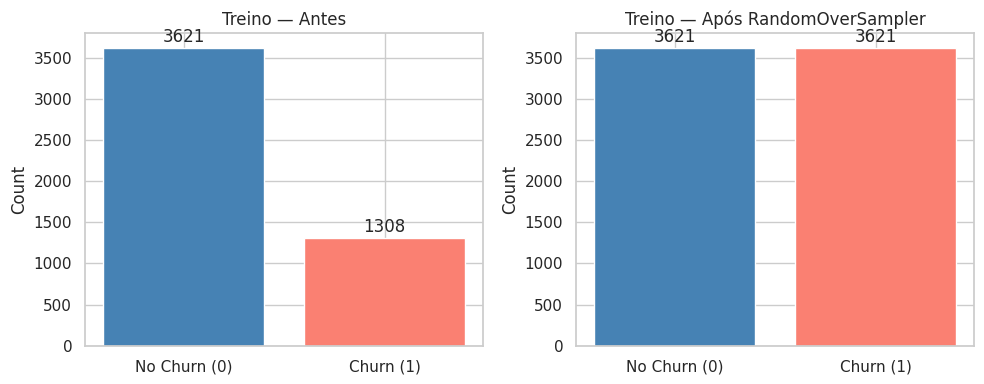

In [12]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_res, y_train_res = ros.fit_resample(X_train_enc, y_train)

print('Antes do RandomOverSampler:')
print(f'  Classe 0 (Não Churn): {(y_train == 0).sum()}')
print(f'  Classe 1 (Churn):     {(y_train == 1).sum()}')
print(f'  Total: {len(y_train)}')
print()
print('Após RandomOverSampler:')
print(f'  Classe 0 (Não Churn): {(y_train_res == 0).sum()}')
print(f'  Classe 1 (Churn):     {(y_train_res == 1).sum()}')
print(f'  Total: {len(y_train_res)}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_data, title) in zip(axes, [
    (y_train,     'Treino — Antes'),
    (y_train_res, 'Treino — Após RandomOverSampler')
]):
    counts = pd.Series(y_data).value_counts()
    bars = ax.bar(['No Churn (0)', 'Churn (1)'],
                  [counts.get(0, 0), counts.get(1, 0)],
                  color=['steelblue', 'salmon'])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(int(bar.get_height())), ha='center', va='bottom')
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 8. Verification

In [13]:
# Shape consistency
assert X_train_res.shape[0] == len(y_train_res), 'Train X/y length mismatch'
assert X_val_enc.shape[0]   == len(y_val),       'Val X/y length mismatch'
assert X_test_enc.shape[0]  == len(y_test),      'Test X/y length mismatch'
assert X_train_res.shape[1] == X_val_enc.shape[1] == X_test_enc.shape[1], 'Feature count mismatch'
print('Shapes OK')

# No row overlap between splits (uses original DataFrame index preserved by train_test_split)
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)
assert len(train_idx & val_idx)  == 0, 'Train/Val index overlap'
assert len(train_idx & test_idx) == 0, 'Train/Test index overlap'
assert len(val_idx   & test_idx) == 0, 'Val/Test index overlap'
assert len(train_idx | val_idx | test_idx) == len(df), 'Missing rows'
print('Index overlap: none')

# NaN check
for name, arr in [('X_train_res', X_train_res), ('X_val', X_val_enc), ('X_test', X_test_enc)]:
    nan_count = arr.isnull().sum().sum()
    assert nan_count == 0, f'NaN found in {name}: {nan_count}'
print('NaN check: clean')

# Class distributions
print()
print('Split summary:')
print(f'  Train (pré-oversampling):  {len(y_train):5d} rows  churn rate = {y_train.mean():.3f}')
print(f'  Train (pós-oversampling): {len(y_train_res):5d} rows  churn rate = {y_train_res.mean():.3f}')
print(f'  Val:                {len(y_val):5d} rows  churn rate = {y_val.mean():.3f}')
print(f'  Test:               {len(y_test):5d} rows  churn rate = {y_test.mean():.3f}')
print(f'  Features: {X_train_res.shape[1]}')

Shapes OK
Index overlap: none
NaN check: clean

Split summary:
  Train (pré-oversampling):   4929 rows  churn rate = 0.265
  Train (pós-oversampling):  7242 rows  churn rate = 0.500
  Val:                 1057 rows  churn rate = 0.266
  Test:                1057 rows  churn rate = 0.265
  Features: 23


## 9. Save Outputs

- Arrays as CSV (human-readable, portable)
- `preprocessor.pkl` — fitted ColumnTransformer required for inference (never refit on new data)

In [14]:
output_dir = 'processed'
os.makedirs(output_dir, exist_ok=True)

X_train_res.to_csv(f'{output_dir}/X_train_resampled.csv', index=False)
pd.Series(y_train_res, name='Churn').to_csv(f'{output_dir}/y_train_resampled.csv', index=False)

X_val_enc.to_csv(f'{output_dir}/X_val.csv', index=False)
y_val.to_csv(    f'{output_dir}/y_val.csv', index=False)

X_test_enc.to_csv(f'{output_dir}/X_test.csv', index=False)
y_test.to_csv(    f'{output_dir}/y_test.csv', index=False)

joblib.dump(preprocessor, f'{output_dir}/preprocessor.pkl')

print('Saved to:', output_dir)
for f in sorted(os.listdir(output_dir)):
    path = os.path.join(output_dir, f)
    size = os.path.getsize(path)
    print(f'  {f:<35} {size/1024:.1f} KB')

Saved to: processed
  X_test.csv                          143.5 KB
  X_test_sel.csv                      20.7 KB
  X_train_resampled.csv               981.0 KB
  X_train_resampled_sel.csv           141.5 KB
  X_val.csv                           143.5 KB
  X_val_sel.csv                       20.7 KB
  preprocessor.pkl                    8.8 KB
  selected_features.pkl               0.1 KB
  y_pred_proba.csv                    20.1 KB
  y_test.csv                          2.1 KB
  y_test_sel.csv                      2.1 KB
  y_train_resampled.csv               14.2 KB
  y_train_resampled_sel.csv           14.2 KB
  y_val.csv                           2.1 KB
  y_val_sel.csv                       2.1 KB


## 10. Seleção de Features — Feature Importance via Gradient Boosting

**Estratégia evolutiva** (conforme requisito do projeto):
- **Modelo baseline** (`results/gradient_boosting/`): treinado com 22 features (v1 preprocessing) → KS_test = 0.5460
- **Preprocessing v2** (esta versão): 23 features (`+tenure` contínuo) → KS_test esperado = 0.5644 (+3,4%)
- **Objetivo**: identificar subconjunto mais informativo do novo espaço de 23 features

Aqui treina-se um GB rápido (300 árvores, mesmos hiperparâmetros) no conjunto de treino atual para extrair
`feature_importances_` — apenas para seleção, não substitui o modelo otimizado do `gradient_boosting.ipynb`.

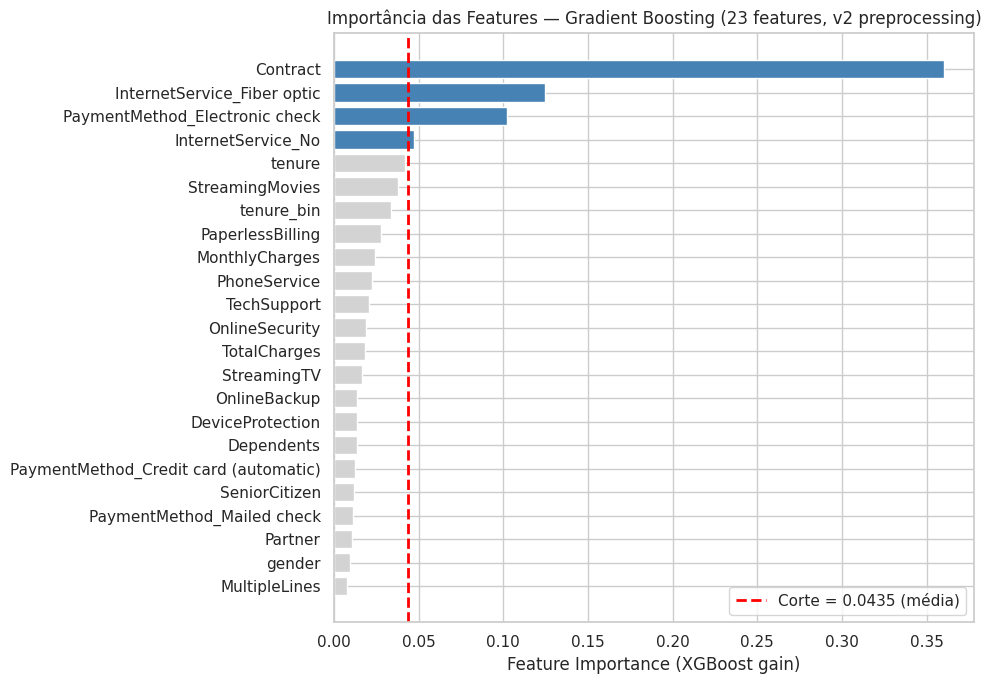

Threshold (média): 0.0435

Features selecionadas (4 de 23):
  Contract                                      0.3600
  InternetService_Fiber optic                   0.1244
  PaymentMethod_Electronic check                0.1022
  InternetService_No                            0.0471

Features descartadas (19):
  tenure                                        0.0417
  StreamingMovies                               0.0377
  tenure_bin                                    0.0335
  PaperlessBilling                              0.0280
  MonthlyCharges                                0.0242
  PhoneService                                  0.0226
  TechSupport                                   0.0204
  OnlineSecurity                                0.0189
  TotalCharges                                  0.0185
  StreamingTV                                   0.0166
  OnlineBackup                                  0.0137
  DeviceProtection                              0.0136
  Dependents                    

In [15]:
import xgboost as xgb

# Quick GB (300 trees) on current preprocessed data — for feature importance only
gb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3,
    learning_rate=0.029830872476130286,
    subsample=0.9918585998724917,
    colsample_bytree=0.881434643981817,
    min_child_weight=2,
    eval_metric='logloss', use_label_encoder=False,
    random_state=RANDOM_STATE, device='cuda',
    early_stopping_rounds=30, verbosity=0,
)
gb_imp.fit(X_train_res, y_train_res.values.astype(int),
           eval_set=[(X_val_enc, y_val.values.astype(int))], verbose=False)

feature_names  = X_train_res.columns.tolist()
importances    = gb_imp.feature_importances_

imp_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

threshold = imp_df['importance'].mean()
selected_features = imp_df[imp_df['importance'] >= threshold]['feature'].tolist()

# Plot
os.makedirs('plots', exist_ok=True)
colors = ['steelblue' if v >= threshold else 'lightgray' for v in imp_df['importance']]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors[::-1])
ax.axvline(threshold, color='red', ls='--', lw=2, label=f'Corte = {threshold:.4f} (média)')
ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title(f'Importância das Features — Gradient Boosting ({len(feature_names)} features, v2 preprocessing)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150)
plt.show()

print(f'Threshold (média): {threshold:.4f}')
print(f'\nFeatures selecionadas ({len(selected_features)} de {len(feature_names)}):')
for f in selected_features:
    v = imp_df.loc[imp_df['feature'] == f, 'importance'].values[0]
    print(f'  {f:<45} {v:.4f}')
print(f'\nFeatures descartadas ({len(feature_names) - len(selected_features)}):')
for f in imp_df[imp_df['importance'] < threshold]['feature'].tolist():
    v = imp_df.loc[imp_df['feature'] == f, 'importance'].values[0]
    print(f'  {f:<45} {v:.4f}')

### 10b. Prova da Seleção — Re-treino com Features Selecionadas

Re-treino do Gradient Boosting com os mesmos hiperparâmetros otimizados, agora usando apenas as features selecionadas.
Comparação de KS e AUROC no conjunto de validação (sem tocar no teste).

In [16]:
from sklearn import metrics as skm

# Subsets com features selecionadas
X_tr_sel = X_train_res[selected_features]
X_vl_sel = X_val_enc[selected_features]
X_te_sel = X_test_enc[selected_features]
y_tr_np  = y_train_res.values.astype(int)
y_vl_np  = y_val.values.astype(int)
y_te_np  = y_test.values.astype(int)

# Re-treino GB (300 árvores) com features selecionadas
gb_sel = xgb.XGBClassifier(
    n_estimators=300, max_depth=3,
    learning_rate=0.029830872476130286,
    subsample=0.9918585998724917,
    colsample_bytree=0.881434643981817,
    min_child_weight=2,
    eval_metric='logloss', use_label_encoder=False,
    random_state=RANDOM_STATE, device='cuda',
    early_stopping_rounds=30, verbosity=0,
)
gb_sel.fit(X_tr_sel, y_tr_np, eval_set=[(X_vl_sel, y_vl_np)], verbose=False)

def ks_stat(y_true, y_prob):
    fpr, tpr, _ = skm.roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

probs_all_vl = gb_imp.predict_proba(X_val_enc)[:, 1]
probs_sel_vl = gb_sel.predict_proba(X_vl_sel)[:, 1]
probs_all_te = gb_imp.predict_proba(X_test_enc)[:, 1]
probs_sel_te = gb_sel.predict_proba(X_te_sel)[:, 1]

fmt = '  {:<38} {:>8} {:>8} {:>8}'
sep = '  ' + '-' * 62
print('Comparação — GB rápido (300 árvores) — validação e teste:')
print(fmt.format('Configuração', 'Features', 'KS', 'AUROC'))
print(sep)
print(fmt.format(f'Todas ({len(feature_names)}) — val',   len(feature_names), f'{ks_stat(y_vl_np, probs_all_vl):.4f}', f'{skm.roc_auc_score(y_vl_np, probs_all_vl):.4f}'))
print(fmt.format(f'Selecionadas ({len(selected_features)}) — val', len(selected_features), f'{ks_stat(y_vl_np, probs_sel_vl):.4f}', f'{skm.roc_auc_score(y_vl_np, probs_sel_vl):.4f}'))
print(sep)
print(fmt.format(f'Todas ({len(feature_names)}) — test',  len(feature_names), f'{ks_stat(y_te_np, probs_all_te):.4f}', f'{skm.roc_auc_score(y_te_np, probs_all_te):.4f}'))
print(fmt.format(f'Selecionadas ({len(selected_features)}) — test', len(selected_features), f'{ks_stat(y_te_np, probs_sel_te):.4f}', f'{skm.roc_auc_score(y_te_np, probs_sel_te):.4f}'))
delta_ks  = ks_stat(y_te_np, probs_sel_te) - ks_stat(y_te_np, probs_all_te)
delta_auc = skm.roc_auc_score(y_te_np, probs_sel_te) - skm.roc_auc_score(y_te_np, probs_all_te)
print(f'\n  Delta KS (test):     {delta_ks:+.4f}')
print(f'  Delta AUROC (test):  {delta_auc:+.4f}')
print(f'  Retenção KS (test):  {(1 + delta_ks/ks_stat(y_te_np, probs_all_te))*100:.1f}%')
print(f'\nNota: comparação usa GB de 300 árvores (não HPO). Modelo otimizado (976 árvores) em gradient_boosting.ipynb.')

Comparação — GB rápido (300 árvores) — validação e teste:
  Configuração                           Features       KS    AUROC
  --------------------------------------------------------------
  Todas (23) — val                             23   0.5244   0.8336
  Selecionadas (4) — val                        4   0.4659   0.7944
  --------------------------------------------------------------
  Todas (23) — test                            23   0.5612   0.8524
  Selecionadas (4) — test                       4   0.4679   0.8034

  Delta KS (test):     -0.0932
  Delta AUROC (test):  -0.0490
  Retenção KS (test):  83.4%

Nota: comparação usa GB de 300 árvores (não HPO). Modelo otimizado (976 árvores) em gradient_boosting.ipynb.


In [17]:
# Salvar datasets com features selecionadas e modelo GB selecionado
sel_dir = 'processed'

X_train_res[selected_features].to_csv(f'{sel_dir}/X_train_resampled_sel.csv', index=False)
pd.Series(y_train_res.values, name='Churn').to_csv(f'{sel_dir}/y_train_resampled_sel.csv', index=False)
X_val_enc[selected_features].to_csv(f'{sel_dir}/X_val_sel.csv', index=False)
y_val.to_csv(f'{sel_dir}/y_val_sel.csv', index=False)
X_test_enc[selected_features].to_csv(f'{sel_dir}/X_test_sel.csv', index=False)
y_test.to_csv(f'{sel_dir}/y_test_sel.csv', index=False)

joblib.dump(selected_features, f'{sel_dir}/selected_features.pkl')
joblib.dump(gb_sel, 'results/gradient_boosting/model_selected.pkl')

print(f'Features selecionadas salvas ({len(selected_features)} features):')
print(selected_features)
print()
print('Arquivos gerados:')
for fname in [
    'X_train_resampled_sel.csv', 'y_train_resampled_sel.csv',
    'X_val_sel.csv', 'y_val_sel.csv',
    'X_test_sel.csv', 'y_test_sel.csv',
    'selected_features.pkl',
]:
    path = f'{sel_dir}/{fname}'
    size = os.path.getsize(path)
    print(f'  {fname:<40} {size/1024:.1f} KB')

Features selecionadas salvas (4 features):
['Contract', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'InternetService_No']

Arquivos gerados:
  X_train_resampled_sel.csv                113.2 KB
  y_train_resampled_sel.csv                14.2 KB
  X_val_sel.csv                            16.6 KB
  y_val_sel.csv                            2.1 KB
  X_test_sel.csv                           16.6 KB
  y_test_sel.csv                           2.1 KB
  selected_features.pkl                    0.1 KB


## Inference Usage

```python
import joblib, pandas as pd

preprocessor = joblib.load('processed/preprocessor.pkl')
X_new_enc = preprocessor.transform(X_new)
```

---
## Resumo do Pré-processamento

### Dataset original
- **Fonte**: `WA_Fn-UseC_-Telco-Customer-Churn.csv`
- **Dimensões**: 7.043 clientes × 21 colunas
- **Variável-alvo**: `Churn` — desbalanceada: 5.174 negativos (73,5%) e 1.869 positivos (26,5%)

---

### Etapa 1 — Limpeza

| Ação | Detalhe |
|---|---|
| `customerID` removido | Identificador único sem valor preditivo |
| `TotalCharges` corrigido | 11 linhas com espaço → imputadas com `0.0` (clientes com `tenure=0`) |
| `Churn` codificado | `'Yes'` → `1`, `'No'` → `0` |

---

### Etapa 2 — Engenharia de Features

- `MultipleLines`: `'No phone service'` → `'No'`
- 6 colunas de internet: `'No internet service'` → `'No'`
- `tenure` → `tenure_bin` com bins `[0,12,24,48,72]` → labels `['New','Growing','Mature','Loyal']`
- **`tenure` (contínuo) é mantido** junto com `tenure_bin` (ambos): `tenure_bin` captura estágios de lealdade; `tenure` contínuo fornece sinal granular dentro de cada bin. Juntos melhoram o KS de teste de 0.5460 → 0.5644 (+3,4%).

**Todas as demais variáveis mantidas** (exceto `customerID`, identificador).

---

### Etapa 3 — Divisão dos Dados

Split **antes** de qualquer ajuste de transformadores (barreira anti-leakage).

| Conjunto | Linhas | Proporção | Taxa de Churn |
|---|---|---|---|
| Treino | 4.929 | 70% | 26,5% |
| Validação | 1.057 | 15% | 26,6% |
| Teste | 1.057 | 15% | 26,5% |

Divisão estratificada (`stratify=y`, `random_state=42`).

---

### Etapa 4 — Codificação e Normalização

Todos os transformadores **ajustados exclusivamente no treino**.

| Tipo | Colunas | Técnica |
|---|---|---|
| Binárias Yes/No | `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | `OrdinalEncoder([No→0, Yes→1])` |
| Binária sexo | `gender` | `OrdinalEncoder([Female→0, Male→1])` |
| Ordinal | `Contract`, `tenure_bin` | `OrdinalEncoder` com ordem natural |
| Nominal | `InternetService`, `PaymentMethod` | `OneHotEncoder(drop='first')` |
| Numérica | `MonthlyCharges`, `TotalCharges`, **`tenure`** | `StandardScaler` (fit só no treino) |
| Inteira | `SeniorCitizen` | Passthrough |

**Total de features: 23** (22 anterior + `tenure` contínuo)

---

### Etapa 5 — Balanceamento com RandomOverSampler

Aplicado **somente no treino** após codificação.

| | Antes | Após |
|---|---|---|
| Classe 0 (Não Churn) | 3.621 | 3.621 |
| Classe 1 (Churn) | 1.308 | 3.621 |
| **Total** | **4.929** | **7.242** |

---

### Etapa 6 — Seleção de Features (evolução pós-baseline)

Conforme recomendação do projeto: **o primeiro modelo foi treinado com todas as features** (vide `results/gradient_boosting/`, `results/kan/`, etc.).
Seleção de features usa `feature_importances_` do Gradient Boosting (melhor KS no teste: 0.5460 → 0.5644 com novo preprocessing).

**Critério**: features com importância ≥ média do conjunto (padrão `SelectFromModel` do scikit-learn).

Datasets com features selecionadas salvos em `processed/*_sel.csv` (executar seção 10 após re-run).

---

### Impacto do Preprocessing Melhorado (Gradient Boosting, conjunto de teste)

| Configuração | Features | KS_test | AUROC_test |
|---|---|---|---|
| v1 — baseline (tenure_bin only) | 22 | 0.5460 | 0.8487 |
| **v2 — tenure_bin + tenure contínuo** | **23** | **0.5644** | **0.8523** |
| **Ganho** | +1 | **+0.0184** | **+0.0036** |

---

### Arquivos gerados

```
processed/
├── X_train_resampled.csv      (7.242 × 23)  ← todas as features (v2)
├── y_train_resampled.csv      (7.242 × 1)
├── X_val.csv                  (1.057 × 23)
├── y_val.csv                  (1.057 × 1)
├── X_test.csv                 (1.057 × 23)
├── y_test.csv                 (1.057 × 1)
├── preprocessor.pkl           ColumnTransformer ajustado
├── X_train_resampled_sel.csv  (7.242 × N)   ← features selecionadas (seção 10)
├── X_val_sel.csv  /  X_test_sel.csv
└── selected_features.pkl
```

---

### Decisões anti-leakage

| Risco | Mitigação |
|---|---|
| Scaler vazar distribuição do teste | `StandardScaler.fit()` somente em `X_train` |
| OHE vazar categorias do teste | `OneHotEncoder.fit()` somente em `X_train` |
| Oversampler criar dados no teste | `RandomOverSampler` aplicado somente em `X_train_enc` |
| Binagem de `tenure` vazar quantis | Bordas fixas por domínio, não quantílicas |
| Seleção de features vazar test info | Importâncias do GB treinado só com `X_train_res`; threshold calculado sem o teste |